In [2]:
pip install pandas numpy matplotlib seaborn scipy requests jupyter biopython

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [55]:
import pandas as pd

# Importing the data from GWAS Catalogue
gwas = pd.read_csv(
    "../data/Breast_Cancer_GWAS.tsv",
    sep="\t"
)

# Keeping only the SNP with pathological breast cancer and a relevant p-value
breast = gwas[
    (gwas["traitName"].str.contains("breast cancer", case=False)) &
    (gwas["pValue"] < 5e-8)
]

# Splitting the location into chromosome and base pair
breast["Chromosome"] = breast["locations"].str.split(":").str[0]
breast["BasePair"] = breast["locations"].str.split(":").str[1]

# Renaming the riskAllele as SNP
breast["SNP"] = breast["riskAllele"]
breast.head()

/var/folders/mf/pqdx96c55v1g4nt556l799l80000gn/T/ipykernel_10822/3787842718.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  breast["Chromosome"] = breast["locations"].str.split(":").str[0]
/var/folders/mf/pqdx96c55v1g4nt556l799l80000gn/T/ipykernel_10822/3787842718.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  breast["BasePair"] = breast["locations"].str.split(":").str[1]
/var/folders/mf/pqdx96c55v1g4nt556l799l80000gn/T/ipykernel_10822/3787842718.py:12: SettingWithCopyWarning: 
A value is trying 

,riskAllele,pValue,pValueAnnotation,riskFrequency,orValue,beta,ci,mappedGenes,traitName,efoTraits,bgTraits,accessionId,locations,pubmedId,author,Chromosome,BasePair,SNP
0,rs8030394-?,1.000000e-08,-,NR,2.47,-,[1.81-3.37],THSD4,15-year breast cancer-specific survival (ER po...,"Her2-receptor negative breast cancer,estrogen-...",-,GCST90029047,15:71344902,34407845,Morra A,15,71344902,rs8030394-?
1,rs62192052-?,3.000000e-09,-,NR,0.15,-,[0.08-0.28],DNER,15-year breast cancer-specific survival (ER po...,"Her2-receptor negative breast cancer,estrogen-...",-,GCST90029048,2:229507632,34407845,Morra A,2,229507632,rs62192052-?
2,rs13258434-G,2.000000e-09,-,NR,-,0.028 unit increase,[0.018-0.038],"LINC02845,NACA4P",Breast cancer subtype (triple negative vs lumi...,"triple-negative breast carcinoma,Her2-receptor...",-,GCST90446472,8:101379857,38832928,Sun X,8,101379857,rs13258434-G
3,rs1243184-T,2.000000e-08,-,NR,-,0.025 unit increase,[0.017-0.033],MLLT10,Breast cancer subtype (triple negative vs lumi...,"triple-negative breast carcinoma,Her2-receptor...",-,GCST90446472,10:21643008,38832928,Sun X,10,21643008,rs1243184-T
4,rs6663303-C,1.000000e-08,-,NR,-,0.03 unit increase,[0.016-0.044],LGR6,Breast cancer subtype (HER2-enriched-like vs l...,"HER2 positive breast carcinoma,luminal A breas...",-,GCST90446469,1:202208798,38832928,Sun X,1,202208798,rs6663303-C


In [81]:
# Checking the number of SNPs
n_variants = breast["riskAllele"].nunique()
print("number of SNP: ",n_variants)

# Creating a table with the number of SNPs divided by Chromosome number
chromosome_table = (
    breast["Chromosome"]
    .value_counts()
    .reset_index()
)

chromosome_table.columns = [
    "Chromosome",
    "Number_of_SNPs"
]

chromosome_table = chromosome_table.sort_values(
    "Chromosome"
)

chromosome_table

number of SNP:  1353


,Chromosome,Number_of_SNPs
4,1.0,127
3,2.0,136
7,3.0,100
16,4.0,48
0,5.0,205
2,6.0,146
14,7.0,54
5,8.0,103
13,9.0,64
1,10.0,161


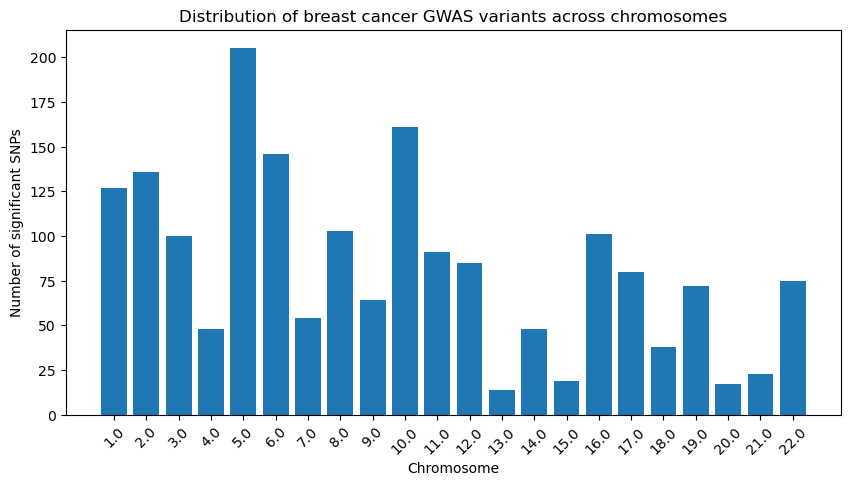

In [83]:
import matplotlib.pyplot as plt

# Formatting the graph representing the number of SNPs per each chromosome
plt.figure(figsize=(10,5))

plt.bar(
    chromosome_table["Chromosome"].astype(str),
    chromosome_table["Number_of_SNPs"]
)

plt.xlabel("Chromosome")
plt.ylabel("Number of significant SNPs")
plt.title(
    "Distribution of breast cancer GWAS variants across chromosomes"
)

plt.xticks(rotation=45)

plt.show()

In [86]:
import numpy as np

# Sort SNPs by Chromosome number and then Base Pair
manhattan_data = manhattan_data.sort_values(
    ["Chromosome", "BasePair"]
).copy()

chromosomes = sorted(
    manhattan_data["Chromosome"].unique()
)

# Creates an empty column needed for the x-axis
manhattan_data["BP_cum_equal"] = 0

# Creates an empty dictionary
chrom_centers = {}

for i, chrom in enumerate(chromosomes):

    # Creates a true/false filter to check chromosome vs loop iteration
    mask = manhattan_data["Chromosome"] == chrom
    
    # Get chromosome length through the biggest SNP in the data
    chrom_length = (
        manhattan_data.loc[mask, "BasePair"].max()
    )
    
    # Scale SNP according to chromosome length: between 0 and 1
    scaled_position = (
        manhattan_data.loc[mask, "BasePair"] 
        / chrom_length
    )
    
    # Put each chromosome in its own equally-sized block
    manhattan_data.loc[mask, "BP_cum_equal"] = (
        i + scaled_position
    )
    
    # Position of chromosome label
    chrom_centers[chrom] = i + 0.5

/var/folders/mf/pqdx96c55v1g4nt556l799l80000gn/T/ipykernel_10822/2411564460.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00793707 0.00793708 0.01497605 0.03786898 0.04342626 0.04342626
 0.04343704 0.04343704 0.04343704 0.04343704 0.04343704 0.04343704
 0.04343704 0.04356027 0.04368213 0.04368213 0.06477465 0.06620587
 0.07640787 0.07640787 0.09161486 0.13823097 0.16915949 0.16915949
 0.17228873 0.182122   0.19074322 0.19074322 0.19074322 0.20829438
 0.21082455 0.21086213 0.36099222 0.36255382 0.36255382 0.3636788
 0.36374996 0.38859519 0.38866041 0.45315361 0.45328771 0.45346609
 0.45349585 0.46979922 0.47092573 0.4709361  0.4709361  0.4709361
 0.4709361  0.48657184 0.48657184 0.49589546 0.49620959 0.49631447
 0.50077052 0.50249445 0.50249445 0.50249445 0.50249445 0.50249445
 0.50249445 0.50249445 0.50249445 0.50249445 0.50249445 0.50314109
 0.60251271 0.60275982 0.60275982 0.60275982 0.619894

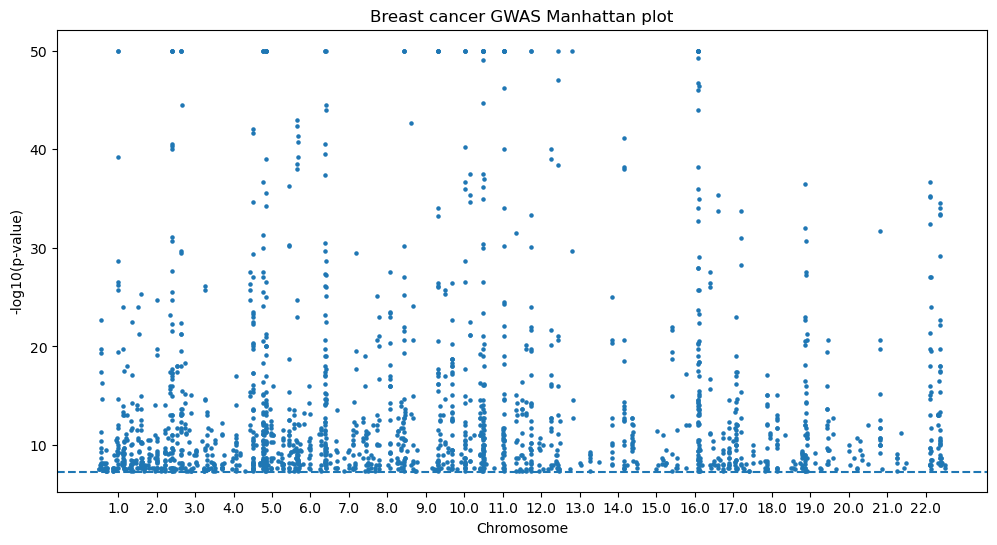

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# Remove zero p-values (otherwise -log10(0) = infinity)
manhattan_data = manhattan_data[
    manhattan_data["pValue"] > 0
].copy()

# Calculate -log10(p)
manhattan_data["minus_log10_p"] = (
    -np.log10(manhattan_data["pValue"])
)

# Avoid extreme values dominating the plot
manhattan_data["minus_log10_p"] = (
    manhattan_data["minus_log10_p"]
    .clip(upper=50)
)

# Plotting the figure
plt.figure(figsize=(12,6))

plt.scatter(
    manhattan_data["BP_cum_equal"],
    manhattan_data["minus_log10_p"],
    s=5
)

plt.axhline(
    -np.log10(5e-8),
    linestyle="--"
)

plt.xticks(
    list(chrom_centers.values()),
    list(chrom_centers.keys())
)

plt.xlabel("Chromosome")
plt.ylabel("-log10(p-value)")
plt.title(
    "Breast cancer GWAS Manhattan plot"
)

plt.show()